<a href="https://colab.research.google.com/github/MarioPEL58/Finance/blob/main/frontiera_efficiente_da_yf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
# See which indexes are available here: https://github.com/paolocole/Stock-Indexes-Historical-Data/tree/main/DAILY/NET

tickers_list=  ["0P0000M2UJ.F",
                "0P0000TM60",
                "0P0000ZNSK.F",
                "0P00016TO5.F",
                "0P00019MC0.F",
                "0P0001CJHB.F",
                "0P0001CJHE.F",
                "0P0001E2AQ.F",
                "0P0001FLNU.F",
                "0P0001HV3A",
                "0P0001HV4N.F",
                "0P0001K4MH.F",
                "0P0001PBIM.F",
                "0P0001PL98.F",
                "0P0001PPS5.F",
                "0P0001PQG4.F",
                "0P0001PQG5.F",
                "0P0001R92D.F",
                "0P0001RC7E.F",
                "0P0001RCEO.F",
                "0P0001TAAN.F",
                "0P0001X0QU.F"]
my_weights =[0.105564359057738,
              0.0159179847461283,
              0.0174713274309024,
              0.0622921801168455,
              0.0114790629534841,
              0.0293923316830278,
              0.0776447969461647,
              0.0359212723771287,
              0.0326456721301979,
              0.0217484636815093,
              0.0707935250523972,
              0.0373292386150762,
              0.0318520879895594,
              0.00615755656754663,
              0.0374077000502637,
              0.0514008417459006,
              0.0663401508571234,
              0.0423335283245297,
              0.0641062859911563,
              0.0647924845181543,
              0.0593166706430147,
              0.0580924785221508]
ticker_to_name = {
"0P0000M2UJ.F": "FIRST EAGL AMUND INT",
"0P0000TM60": "AMUNDI EQ MENA G $ C",
"0P0000ZNSK.F": "AMUNDI JAP EQ VA G2C",
"0P00016TO5.F": "CPR INV DYNAMIC F",
"0P00019MC0.F": "CPR INV GI D OP A CA",
"0P0001CJHB.F": "AMUNDI EQ VALUE G EU",
"0P0001CJHE.F": "AMUNDI PIO GLOB EQ G",
"0P0001E2AQ.F": "AMUNDI PIO INC OPP G",
"0P0001FLNU.F": "CPR INVEST CLIMATE A",
"0P0001HV3A": "AMUNDI CHINA EQ GUSD",
"0P0001HV4N.F": "AMUNDI PIO US BOND G",
"0P0001K4MH.F": "CPR INV GLO DIS OP U",
"0P0001PBIM.F": "AMUNDI META 2027 DUE",
"0P0001PL98.F": "AMUNDI FU CH A SH G",
"0P0001PPS5.F": "FCH M&G GLOBAL DVD",
"0P0001PQG4.F": "FCH JPMOR US EQ FO F",
"0P0001PQG5.F": "FCH MOR ST SU EU ST",
"0P0001R92D.F": "CPR INV B&W CLIM 28D",
"0P0001RC7E.F": "FCH BLUEB INV GR EUR",
"0P0001RCEO.F": "FCH FIDELITY EURO BO",
"0P0001TAAN.F": "FCH MUZINICH ENHANCE",
"0P0001X0QU.F": "AMUNDI SVILUP BIL 30"
}

In [4]:
import pandas as pd
import yfinance as yf

def load_data(tickers):
    """
    Scarica i dati storici da Yahoo Finance per una lista di ticker.
    Recupera gli ultimi 10 anni di dati.
    """
    # Scarichiamo i dati per un periodo di 10 anni
    df = yf.download(tickers, period='10y', progress=False, auto_adjust=True)

    # Gestione MultiIndex (quando ci sono più ticker)
    if isinstance(df.columns, pd.MultiIndex):
        if 'Close' in df.columns.levels[0]:
            df = df['Close']
    else:
        # Gestione Ticker singolo
        if 'Close' in df.columns:
            df = df[['Close']]

    return df.sort_index()

# Esecuzione usando la tickers_list definita nella cella precedente
merged_df = load_data(tickers_list)

# Visualizzazione
print(f"Periodo caricato: dal {merged_df.index.min().date()} al {merged_df.index.max().date()}")
print(f"Asset caricati: {len(merged_df.columns)}")
display(merged_df.head())

Periodo caricato: dal 2022-03-04 al 2026-06-25
Asset caricati: 22


Ticker,0P0000M2UJ.F,0P0000TM60,0P0000ZNSK.F,0P00016TO5.F,0P00019MC0.F,0P0001CJHB.F,0P0001CJHE.F,0P0001E2AQ.F,0P0001FLNU.F,0P0001HV3A,...,0P0001PBIM.F,0P0001PL98.F,0P0001PPS5.F,0P0001PQG4.F,0P0001PQG5.F,0P0001R92D.F,0P0001RC7E.F,0P0001RCEO.F,0P0001TAAN.F,0P0001X0QU.F
Date,,,,,,,,,,,,,,,,,,,,,
2022-03-04,NaN,NaN,NaN,1497.150024,NaN,NaN,NaN,NaN,NaN,5.101,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-07,148.389999,226.809998,141.360001,1468.560059,1717.150024,4.682,6.733,5.859,138.789993,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-08,148.830002,227.880005,138.410004,NaN,1715.140015,4.721,6.725,5.849,138.410004,4.788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-09,150.639999,226.369995,138.449997,1468.270020,1749.890015,5.004,6.791,5.803,141.289993,4.798,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-03-10,150.759995,226.029999,144.190002,1466.349976,1745.390015,4.880,6.808,5.835,140.660004,4.771,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Find rows where all columns are present (no NaNs)
mask = merged_df.notna().all(axis=1)

if mask.any():
    # Get the index of the first and last row that has no NaNs
    first_valid = mask.idxmax()
    last_valid = mask[::-1].idxmax()

    # Slice the dataframe from the first fully valid row to the last fully valid row
    merged_df = merged_df.loc[first_valid:last_valid]

print(f"New shape: {merged_df.shape}")
display(merged_df.head())
display(merged_df.tail())

New shape: (228, 22)


Ticker,0P0000M2UJ.F,0P0000TM60,0P0000ZNSK.F,0P00016TO5.F,0P00019MC0.F,0P0001CJHB.F,0P0001CJHE.F,0P0001E2AQ.F,0P0001FLNU.F,0P0001HV3A,...,0P0001PBIM.F,0P0001PL98.F,0P0001PPS5.F,0P0001PQG4.F,0P0001PQG5.F,0P0001R92D.F,0P0001RC7E.F,0P0001RCEO.F,0P0001TAAN.F,0P0001X0QU.F
Date,,,,,,,,,,,,,,,,,,,,,
2025-07-22,172.179993,227.009995,228.929993,1709.030029,2017.640015,6.738,9.519,7.100,181.619995,4.739,...,5.384,3.384,5.781,6.248,5.137,107.744232,5.400,5.383,5.234,5.010
2025-07-23,173.940002,229.839996,234.690002,1721.209961,2028.180054,6.846,9.604,7.117,183.470001,4.810,...,NaN,3.392,5.835,6.273,5.134,108.073929,5.400,5.371,5.238,5.008
2025-07-24,173.729996,229.919998,238.130005,1721.410034,2028.890015,6.897,9.612,7.096,184.169998,4.825,...,NaN,3.403,5.808,6.252,5.112,107.909081,5.381,5.354,5.228,4.992
2025-07-25,173.169998,NaN,236.199997,1726.040039,2041.780029,6.871,9.650,7.118,184.669998,4.774,...,NaN,3.387,5.821,6.291,5.108,107.870293,5.375,5.350,5.231,4.989
2025-07-28,172.470001,229.520004,235.020004,1732.689941,2058.110107,6.854,9.655,7.139,185.050003,4.792,...,NaN,3.433,5.825,6.353,5.119,108.015747,5.386,5.358,5.224,4.998


Ticker,0P0000M2UJ.F,0P0000TM60,0P0000ZNSK.F,0P00016TO5.F,0P00019MC0.F,0P0001CJHB.F,0P0001CJHE.F,0P0001E2AQ.F,0P0001FLNU.F,0P0001HV3A,...,0P0001PBIM.F,0P0001PL98.F,0P0001PPS5.F,0P0001PQG4.F,0P0001PQG5.F,0P0001R92D.F,0P0001RC7E.F,0P0001RCEO.F,0P0001TAAN.F,0P0001X0QU.F
Date,,,,,,,,,,,,,,,,,,,,,
2026-06-10,194.820007,224.889999,313.359985,1873.420044,2361.149902,8.053,11.936,7.784,207.410004,4.613,...,NaN,4.564,6.503,6.864,5.103,109.089996,5.305,5.267,5.265,4.986
2026-06-11,194.690002,225.210007,313.059998,1902.339966,2421.169922,8.054,12.111,7.830,209.970001,4.588,...,NaN,4.581,6.587,7.001,5.118,109.169998,5.314,5.283,5.279,4.992
2026-06-12,197.350006,NaN,316.690002,1914.329956,2422.939941,8.216,12.267,7.844,212.110001,4.675,...,NaN,4.619,6.631,6.999,5.131,109.250000,5.329,5.288,5.275,5.000
2026-06-15,198.960007,230.479996,325.429993,1940.319946,2491.689941,8.255,12.387,7.810,214.860001,4.782,...,NaN,4.811,6.644,7.112,5.148,109.389999,5.344,5.297,5.280,5.007
2026-06-16,198.860001,232.289993,324.649994,1933.310059,2453.179932,8.310,12.412,7.840,214.210007,4.730,...,5.483,4.816,6.597,7.074,5.154,109.389999,5.352,5.307,5.283,5.008


In [6]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 228 entries, 2025-07-22 to 2026-06-16
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   0P0000M2UJ.F  221 non-null    float64
 1   0P0000TM60    172 non-null    float64
 2   0P0000ZNSK.F  209 non-null    float64
 3   0P00016TO5.F  212 non-null    float64
 4   0P00019MC0.F  215 non-null    float64
 5   0P0001CJHB.F  224 non-null    float64
 6   0P0001CJHE.F  224 non-null    float64
 7   0P0001E2AQ.F  224 non-null    float64
 8   0P0001FLNU.F  215 non-null    float64
 9   0P0001HV3A    205 non-null    float64
 10  0P0001HV4N.F  224 non-null    float64
 11  0P0001K4MH.F  214 non-null    float64
 12  0P0001PBIM.F  48 non-null     float64
 13  0P0001PL98.F  208 non-null    float64
 14  0P0001PPS5.F  217 non-null    float64
 15  0P0001PQG4.F  217 non-null    float64
 16  0P0001PQG5.F  220 non-null    float64
 17  0P0001R92D.F  213 non-null    float64
 18  0P0001RC7E.

/tmp/ipykernel_2553/3752465696.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = merged_df.pct_change()


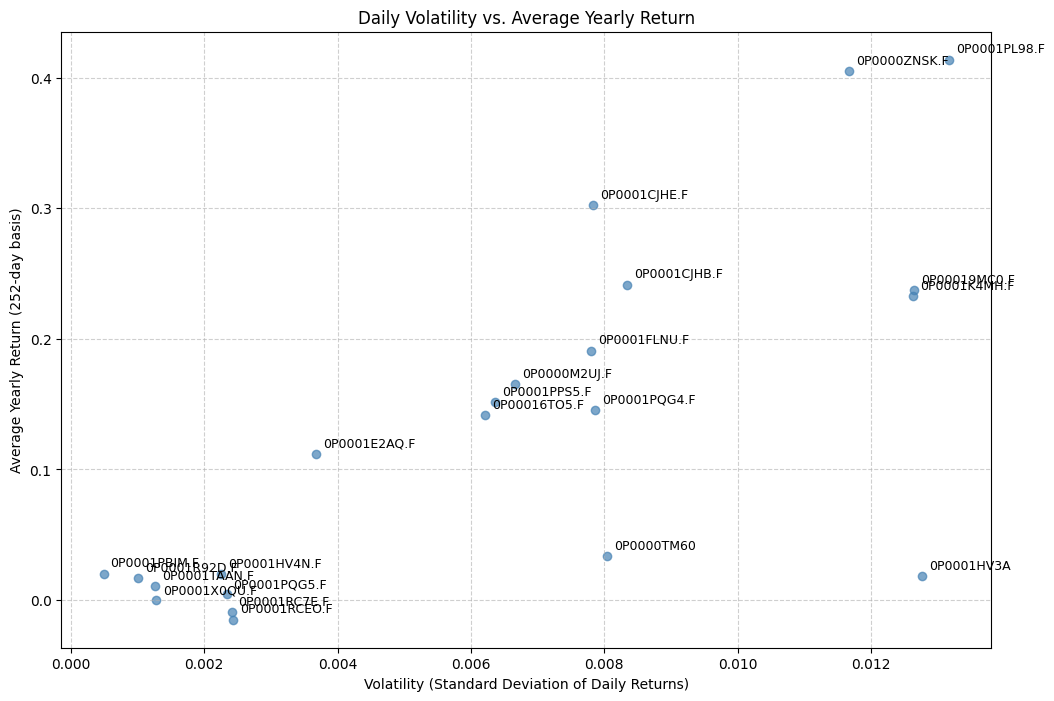

,Yearly Return,Daily Volatility
Ticker,,
0P0000M2UJ.F,0.165550,0.006666
0P0000TM60,0.033634,0.008041
0P0000ZNSK.F,0.405191,0.011672
0P00016TO5.F,0.141764,0.006207
0P00019MC0.F,0.237155,0.012640
0P0001CJHB.F,0.241600,0.008338
0P0001CJHE.F,0.302470,0.007830
0P0001E2AQ.F,0.111777,0.003671
0P0001FLNU.F,0.190926,0.007805


In [7]:
import matplotlib.pyplot as plt

# Calculate daily percentage returns
returns_df = merged_df.pct_change()

# Calculate mean return and volatility (std dev)
# We annualize the return by multiplying by 252 (trading days)
stats = pd.DataFrame({
    'Yearly Return': returns_df.mean() * 252,
    'Daily Volatility': returns_df.std()
})

# Create the scatterplot
plt.figure(figsize=(12, 8))
plt.scatter(stats['Daily Volatility'], stats['Yearly Return'], alpha=0.7, color='steelblue')

# Add labels for each point
for i, txt in enumerate(stats.index):
    plt.annotate(txt, (stats['Daily Volatility'].iloc[i], stats['Yearly Return'].iloc[i]),
                 xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.title('Daily Volatility vs. Average Yearly Return')
plt.xlabel('Volatility (Standard Deviation of Daily Returns)')
plt.ylabel('Average Yearly Return (252-day basis)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

display(stats)

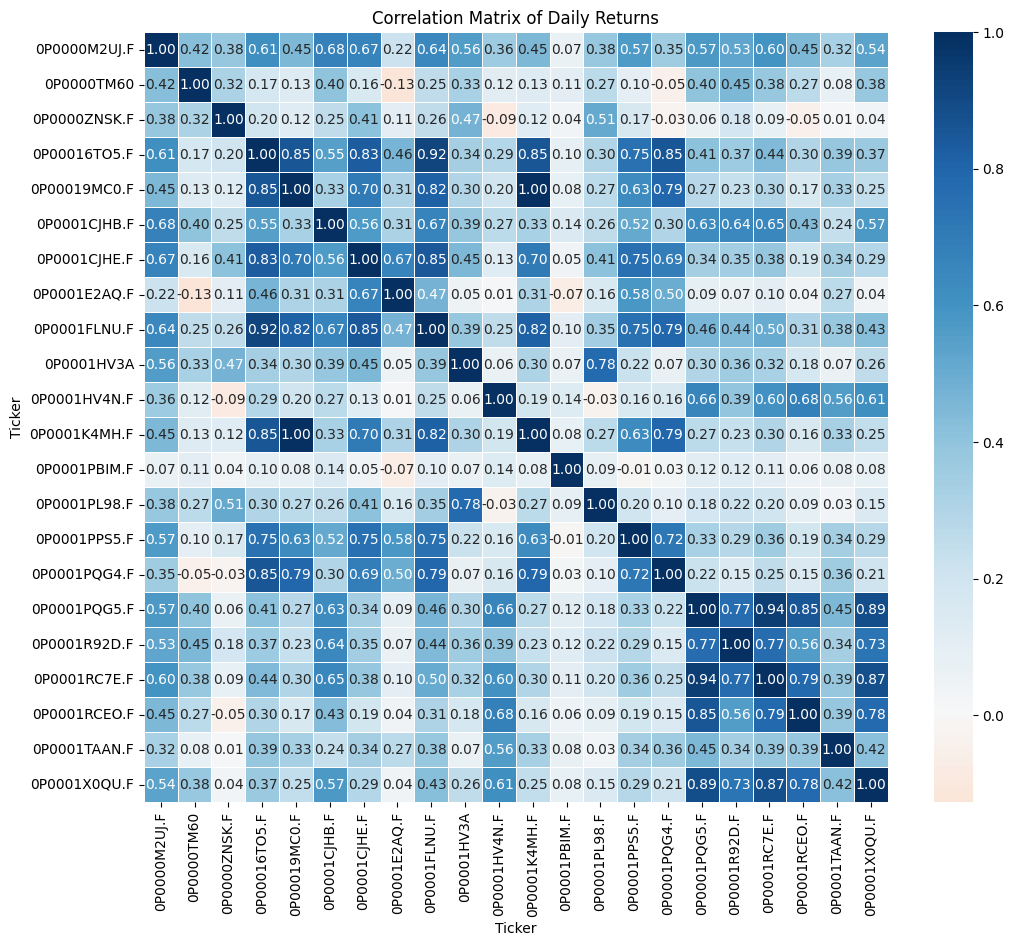

In [8]:
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = returns_df.corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Daily Returns')
plt.show()

/tmp/ipykernel_2553/681145761.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = merged_df.pct_change()


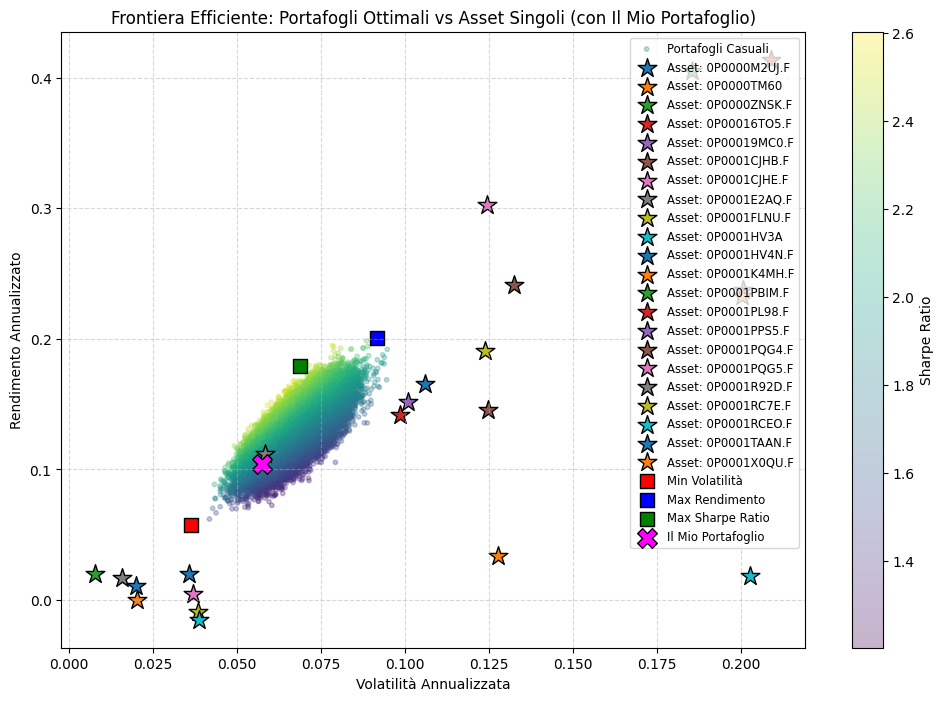

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate daily percentage returns
returns_df = merged_df.pct_change()

# Asset selezionati
#assets = ['USA', 'GERMANY', 'ITALY', 'EUROPE', 'UNITED-KINGDOM','JAPAN','SWITZERLAND','SPAIN','EM-EMERGING-MARKETS']

assets = ['USA','SWITZERLAND','EM-EMERGING-MARKETS','MEXICO']
assets = tickers_list
# assets=['USA','JAPAN','SWITZERLAND','SPAIN','EM-EMERGING-MARKETS']
subset_returns = returns_df[assets].dropna()

# Parametri annualizzati
mean_returns = subset_returns.mean() * 252
cov_matrix = subset_returns.cov() * 252

num_portfolios = 50000
results = np.zeros((3, num_portfolios))
weights_record = []

# Simulazione Monte Carlo
np.random.seed(42)
for i in range(num_portfolios):
    weights = np.random.random(len(assets))
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = results[0,i] / results[1,i]

# Identificazione portafogli ottimali
min_vol_idx = np.argmin(results[1,:])
max_ret_idx = np.argmax(results[0,:])
max_sharpe_idx = np.argmax(results[2,:])

# Calcola rendimento e volatilità del tuo portafoglio
my_portfolio_return = np.sum(np.array(my_weights) * mean_returns)
my_portfolio_std_dev = np.sqrt(np.dot(np.array(my_weights).T, np.dot(cov_matrix, np.array(my_weights))))

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3, label='Portafogli Casuali')
plt.colorbar(label='Sharpe Ratio')

for asset in assets:
    vol = subset_returns[asset].std() * np.sqrt(252)
    ret = mean_returns[asset]
    plt.scatter(vol, ret, marker='*', s=200, edgecolors='black', label=f'Asset: {asset}')

plt.scatter(results[1, min_vol_idx], results[0, min_vol_idx], color='red', marker='s', s=100, edgecolors='black', label='Min Volatilità')
plt.scatter(results[1, max_ret_idx], results[0, max_ret_idx], color='blue', marker='s', s=100, edgecolors='black', label='Max Rendimento')
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], color='green', marker='s', s=100, edgecolors='black', label='Max Sharpe Ratio')

# Aggiungi il tuo portafoglio al plot
plt.scatter(my_portfolio_std_dev, my_portfolio_return, color='magenta', marker='X', s=200, edgecolors='black', label='Il Mio Portafoglio')

plt.title('Frontiera Efficiente: Portafogli Ottimali vs Asset Singoli (con Il Mio Portafoglio)')
plt.xlabel('Volatilità Annualizzata')
plt.ylabel('Rendimento Annualizzato')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [20]:
tolerance = 0.005 # Define a small tolerance for volatility

# Find portfolios with volatility close to my_portfolio_std_dev
close_volatility_indices = np.where(
    (results[1, :] >= my_portfolio_std_dev - tolerance) &
    # (results[1, :] >= my_portfolio_std_dev + tolerance) &
    (results[1, :] <= my_portfolio_std_dev)
)[0]

if len(close_volatility_indices) > 0:
    # Among these, find the one with the maximum return
    highest_return_same_vol_idx = close_volatility_indices[np.argmax(results[0, close_volatility_indices])]

    portfolio_same_vol_return = results[0, highest_return_same_vol_idx]
    portfolio_same_vol_std_dev = results[1, highest_return_same_vol_idx]

    print(f"Portafoglio con volatilità simile ({portfolio_same_vol_std_dev:.2%}) e massimo rendimento ({portfolio_same_vol_return:.2%}):")
    print(f"  Volatilità: {portfolio_same_vol_std_dev:.2%}")
    print(f"  Rendimento: {portfolio_same_vol_return:.2%}")

    # Store the weights of this portfolio for potential display
    optimal_same_vol_weights = weights_record[highest_return_same_vol_idx]

else:
    print(f"Nessun portafoglio simulato trovato con volatilità simile a {my_portfolio_std_dev:.2%}.")
    portfolio_same_vol_return = None
    portfolio_same_vol_std_dev = None
    optimal_same_vol_weights = None

Portafoglio con volatilità simile (5.67%) e massimo rendimento (13.74%):
  Volatilità: 5.67%
  Rendimento: 13.74%


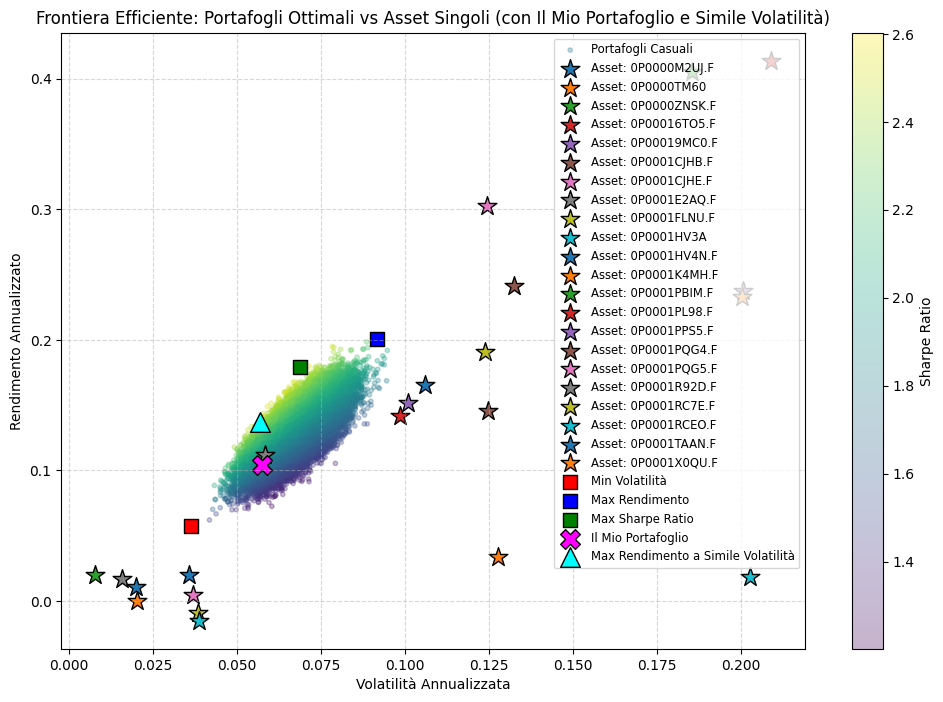

In [21]:
plt.figure(figsize=(12, 8))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3, label='Portafogli Casuali')
plt.colorbar(label='Sharpe Ratio')

for asset in assets:
    vol = subset_returns[asset].std() * np.sqrt(252)
    ret = mean_returns[asset]
    plt.scatter(vol, ret, marker='*', s=200, edgecolors='black', label=f'Asset: {asset}')

plt.scatter(results[1, min_vol_idx], results[0, min_vol_idx], color='red', marker='s', s=100, edgecolors='black', label='Min Volatilità')
plt.scatter(results[1, max_ret_idx], results[0, max_ret_idx], color='blue', marker='s', s=100, edgecolors='black', label='Max Rendimento')
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], color='green', marker='s', s=100, edgecolors='black', label='Max Sharpe Ratio')

# Aggiungi il tuo portafoglio al plot
plt.scatter(my_portfolio_std_dev, my_portfolio_return, color='magenta', marker='X', s=200, edgecolors='black', label='Il Mio Portafoglio')

# Aggiungi il portafoglio con volatilità simile e massimo rendimento
if portfolio_same_vol_return is not None:
    plt.scatter(portfolio_same_vol_std_dev, portfolio_same_vol_return, color='cyan', marker='^', s=200, edgecolors='black', label='Max Rendimento a Simile Volatilità')

plt.title('Frontiera Efficiente: Portafogli Ottimali vs Asset Singoli (con Il Mio Portafoglio e Simile Volatilità)')
plt.xlabel('Volatilità Annualizzata')
plt.ylabel('Rendimento Annualizzato')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [30]:
import pandas as pd

# Format my_weights for display
my_weights_formatted = [f"{w*100:.2f}%" for w in my_weights]

# Ensure optimal_same_vol_weights is available, otherwise fill with 'N/A'
if 'optimal_same_vol_weights' in locals() and optimal_same_vol_weights is not None:
    optimized_weights_formatted = [f"{w*100:.2f}%" for w in optimal_same_vol_weights]
else:
    optimized_weights_formatted = ['N/A'] * len(assets)

summary_stats = pd.DataFrame({
    'Asset': assets,
    'Min Volatilità': [f"{weights_record[min_vol_idx][i]*100:.2f}%" for i in range(len(assets))],
    'Max Rendimento': [f"{weights_record[max_ret_idx][i]*100:.2f}%" for i in range(len(assets))],
    'Max Sharpe Ratio': [f"{weights_record[max_sharpe_idx][i]*100:.2f}%" for i in range(len(assets))],
    'Actual': my_weights_formatted,
    'Optimized': optimized_weights_formatted
})

# Calculate Sharpe Ratio for my portfolio, handling division by zero
my_portfolio_sharpe = 'N/A'
if my_portfolio_std_dev is not None and my_portfolio_std_dev != 0:
    my_portfolio_sharpe = f"{my_portfolio_return / my_portfolio_std_dev:.2f}"

metrics_data = [
    ['---', '---', '---', '---', '---', '---'],
    ['Rendimento Ann.', f"{results[0, min_vol_idx]:.2%}", f"{results[0, max_ret_idx]:.2%}", f"{results[0, max_sharpe_idx]:.2%}", f"{my_portfolio_return:.2%}", f"{portfolio_same_vol_return:.2%}" if portfolio_same_vol_return is not None else 'N/A'],
    ['Volatilità Ann.', f"{results[1, min_vol_idx]:.2%}", f"{results[1, max_ret_idx]:.2%}", f"{results[1, max_sharpe_idx]:.2%}", f"{my_portfolio_std_dev:.2%}", f"{portfolio_same_vol_std_dev:.2%}" if portfolio_same_vol_std_dev is not None else 'N/A'],
    ['Sharpe Ratio', f"{results[2, min_vol_idx]:.2f}", f"{results[2, max_ret_idx]:.2f}", f"{results[2, max_sharpe_idx]:.2f}", my_portfolio_sharpe, f"{portfolio_same_vol_return / portfolio_same_vol_std_dev:.2f}" if portfolio_same_vol_return is not None and portfolio_same_vol_std_dev != 0 else 'N/A']
]

metrics = pd.DataFrame(metrics_data,
                       columns=['Asset', 'Min Volatilità', 'Max Rendimento', 'Max Sharpe Ratio', 'Actual', 'Optimized'])

final_summary = pd.concat([summary_stats, metrics], ignore_index=True)

# Map ticker symbols to names for better readability
final_summary['Asset'] = final_summary['Asset'].replace(ticker_to_name)

print("Dettagli dei Portafogli Ottimali:")
display(final_summary)

Dettagli dei Portafogli Ottimali:


,Asset,Min Volatilità,Max Rendimento,Max Sharpe Ratio,Actual,Optimized
0,FIRST EAGL AMUND INT,2.69%,1.09%,3.64%,10.56%,3.91%
1,AMUNDI EQ MENA G $ C,3.04%,1.68%,3.79%,1.59%,2.67%
2,AMUNDI JAP EQ VA G2C,1.12%,10.15%,10.15%,1.75%,8.86%
3,CPR INV DYNAMIC F,0.12%,4.83%,6.32%,6.23%,3.24%
4,CPR INV GI D OP A CA,0.21%,10.34%,6.08%,1.15%,0.31%
5,AMUNDI EQ VALUE G EU,3.14%,9.23%,3.41%,2.94%,7.19%
6,AMUNDI PIO GLOB EQ G,3.15%,9.46%,9.01%,7.76%,1.69%
7,AMUNDI PIO INC OPP G,8.41%,3.24%,11.01%,3.59%,7.34%
8,CPR INVEST CLIMATE A,0.68%,3.06%,0.08%,3.26%,7.03%
9,AMUNDI CHINA EQ GUSD,1.16%,6.32%,0.20%,2.17%,1.07%


In [31]:
import pandas as pd

# Assicurati che i pesi siano NumPy arrays per facilitare le operazioni
actual_weights = np.array(my_weights)
optimized_weights = np.array(optimal_same_vol_weights)

# Calcola la differenza (Optimized - Actual)
# Un valore positivo indica che si dovrebbe comprare, un valore negativo che si dovrebbe vendere.
weight_differences = optimized_weights - actual_weights

# Crea un DataFrame per visualizzare le differenze
portfolio_adjustment = pd.DataFrame({
    'Asset': assets,
    'Peso Attuale': [f"{w*100:.2f}%" for w in actual_weights],
    'Peso Ottimizzato': [f"{w*100:.2f}%" for w in optimized_weights],
    'Aggiustamento (Optimized - Actual)': [f"{diff*100:.2f}%" for diff in weight_differences]
})

# Map ticker symbols to names for better readability
portfolio_adjustment['Asset'] = portfolio_adjustment['Asset'].replace(ticker_to_name)

print("Aggiustamenti necessari per passare al portafoglio ottimizzato:")
display(portfolio_adjustment)

Aggiustamenti necessari per passare al portafoglio ottimizzato:


,Asset,Peso Attuale,Peso Ottimizzato,Aggiustamento (Optimized - Actual)
0,FIRST EAGL AMUND INT,10.56%,3.91%,-6.65%
1,AMUNDI EQ MENA G $ C,1.59%,2.67%,1.08%
2,AMUNDI JAP EQ VA G2C,1.75%,8.86%,7.11%
3,CPR INV DYNAMIC F,6.23%,3.24%,-2.99%
4,CPR INV GI D OP A CA,1.15%,0.31%,-0.83%
5,AMUNDI EQ VALUE G EU,2.94%,7.19%,4.25%
6,AMUNDI PIO GLOB EQ G,7.76%,1.69%,-6.07%
7,AMUNDI PIO INC OPP G,3.59%,7.34%,3.75%
8,CPR INVEST CLIMATE A,3.26%,7.03%,3.77%
9,AMUNDI CHINA EQ GUSD,2.17%,1.07%,-1.10%


### Distribuzione dei Rendimenti per il Portafoglio Ottimizzato

Per visualizzare la distribuzione dei possibili rendimenti del portafoglio ottimizzato, eseguiamo una simulazione Monte Carlo focalizzata solo su questo portafoglio, utilizzando i suoi pesi, i rendimenti medi degli asset e la matrice di covarianza.

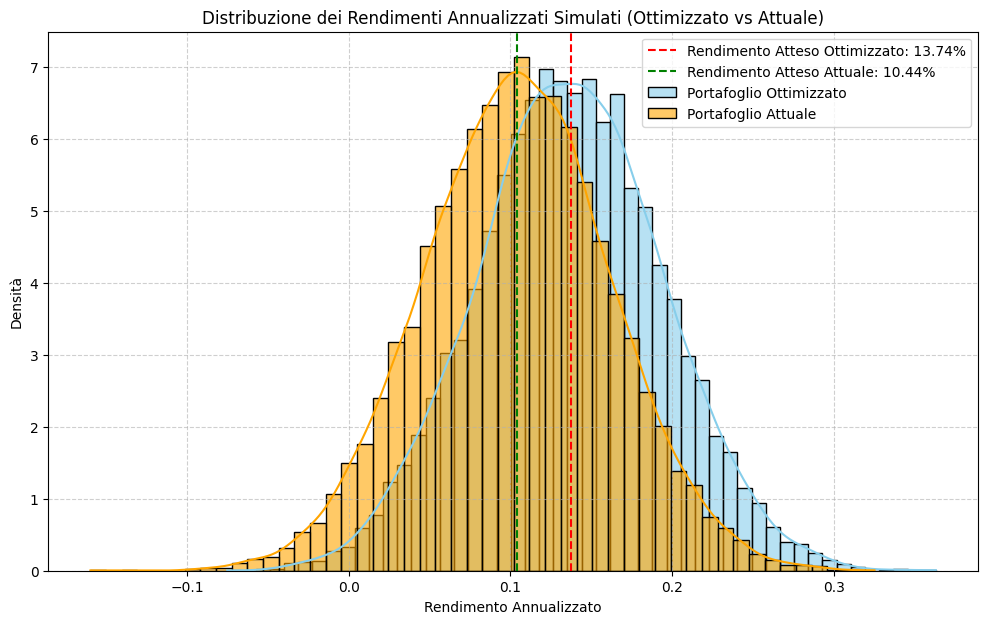

In [32]:
num_simulations = 10000

# Simulate returns for the Optimized Portfolio
# Using the already calculated portfolio_same_vol_return and portfolio_same_vol_std_dev
simulated_returns_optimized = np.random.normal(portfolio_same_vol_return, portfolio_same_vol_std_dev, num_simulations)

# Simulate returns for the Actual Portfolio
# Using the already calculated my_portfolio_return and my_portfolio_std_dev
simulated_returns_actual = np.random.normal(my_portfolio_return, my_portfolio_std_dev, num_simulations)


# Visualizza la distribuzione dei rendimenti simulati
plt.figure(figsize=(12, 7))
sns.histplot(simulated_returns_optimized, bins=50, kde=True, color='skyblue', label='Portafoglio Ottimizzato', stat='density', alpha=0.6)
sns.histplot(simulated_returns_actual, bins=50, kde=True, color='orange', label='Portafoglio Attuale', stat='density', alpha=0.6)

plt.title('Distribuzione dei Rendimenti Annualizzati Simulati (Ottimizzato vs Attuale)')
plt.xlabel('Rendimento Annualizzato')
plt.ylabel('Densità')

plt.axvline(x=portfolio_same_vol_return, color='red', linestyle='--', label=f'Rendimento Atteso Ottimizzato: {portfolio_same_vol_return:.2%}')
plt.axvline(x=my_portfolio_return, color='green', linestyle='--', label=f'Rendimento Atteso Attuale: {my_portfolio_return:.2%}')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
url = "https://raw.githubusercontent.com/paolocole/Stock-Indexes-Historical-Data/main/DAILY/NET/"

elenco = {  "WORLD":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/STANDARD-LARGE-MID-CAP/WORLD.csv",
            "WORLD SMALL CAPS":"EUR/DEVELOPED-MARKETS-DM/Region/NONE/NONE/SMALL-CAP/WORLD-SMALL-CAP.csv",
            "GOLD":"EUR/EXTRA/GOLD.csv"
}

In [12]:
file_bonds = "https://www.paolocoletti.com/wp-content/uploads/youtube/tassi_btp_eurobond.xlsx"
# ESTER is in sheet "ESTER", 11th column Date, 12th column ESTER price (not rate), first row contains headers
# GOV BONDS is in sheet "Eurozone", 1st column Date, 6th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# short GOV BONDS is in sheet "Eurozone", 1st column Date, 2nd column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# long GOV BONDS is in sheet "Eurozone", 1st column Date, 5th column price. FIRST ROW must be excluded, second row contains headers. Beware that dates are in reverse order and that not all days are present (holidays are missing)
# EURIBOR are in sheet "Euribor", column 1 is date with header, columns 2-3-4-5 are euribor 1M 3M 6M 12M, these are prices and not rates.